In this notebook, I will be making observations regarding the data provided in the [CommonLit Readability Prize](https://www.kaggle.com/c/commonlitreadabilityprize/overview).

I have made some submissions in the competitions.
- [Decision Tree with score 0.941](https://www.kaggle.com/aniketsharma00411/commonlit-readability-decision-tree)
- [Random Forest with score 0.780](https://www.kaggle.com/aniketsharma00411/commonlit-readability-random-forest)

I will be using the observations I make in this notebook to improve these models and create further better models using other Regression techniques.

As in the other notebooks, I will be using the [readability](https://pypi.org/project/readability/) Python package to create features from excerpts.

# Initialization

I am using the [readability](https://pypi.org/project/readability/) and [syntok](https://pypi.org/project/syntok/) to evaluate readability of each excerpt and [textblob](https://pypi.org/project/textblob/) for sentiment analysis.

In [1]:
! pip install -q /kaggle/input/readability/readability-0.3.1-py3-none-any.whl
! pip install -q /kaggle/input/syntok/syntok-1.3.1-py3-none-any.whl
from textblob import TextBlob
import readability
import syntok.segmenter as segmenter

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_data = pd.read_csv('/kaggle/input/commonlitreadabilityprize/train.csv')
test_data = pd.read_csv('/kaggle/input/commonlitreadabilityprize/test.csv')

In [3]:
train_data.info()
train_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2834 entries, 0 to 2833
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              2834 non-null   object 
 1   url_legal       830 non-null    object 
 2   license         830 non-null    object 
 3   excerpt         2834 non-null   object 
 4   target          2834 non-null   float64
 5   standard_error  2834 non-null   float64
dtypes: float64(2), object(4)
memory usage: 133.0+ KB


,id,url_legal,license,excerpt,target,standard_error
0,c12129c31,NaN,NaN,When the young people returned to the ballroom...,-0.340259,0.464009
1,85aa80a4c,NaN,NaN,"All through dinner time, Mrs. Fayre was somewh...",-0.315372,0.480805
2,b69ac6792,NaN,NaN,"As Roger had predicted, the snow departed as q...",-0.580118,0.476676
3,dd1000b26,NaN,NaN,And outside before the palace a great garden w...,-1.054013,0.450007
4,37c1b32fb,NaN,NaN,Once upon a time there were Three Bears who li...,0.247197,0.510845


In [4]:
test_data.info()
test_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         7 non-null      object
 1   url_legal  3 non-null      object
 2   license    3 non-null      object
 3   excerpt    7 non-null      object
dtypes: object(4)
memory usage: 352.0+ bytes


,id,url_legal,license,excerpt
0,c0f722661,NaN,NaN,My hope lay in Jack's promise that he would ke...
1,f0953f0a5,NaN,NaN,Dotty continued to go to Mrs. Gray's every nig...
2,0df072751,NaN,NaN,It was a bright and cheerful scene that greete...
3,04caf4e0c,https://en.wikipedia.org/wiki/Cell_division,CC BY-SA 3.0,Cell division is the process by which a parent...
4,0e63f8bea,https://en.wikipedia.org/wiki/Debugging,CC BY-SA 3.0,Debugging is the process of finding and resolv...


In [5]:
pd.read_csv('/kaggle/input/commonlitreadabilityprize/sample_submission.csv')

,id,target
0,c0f722661,0.0
1,f0953f0a5,0.0
2,0df072751,0.0
3,04caf4e0c,0.0
4,0e63f8bea,0.0
5,12537fe78,0.0
6,965e592c0,0.0


# Functions

In [6]:
def sentiment_analysis(text):
    return TextBlob(text).sentiment.polarity

In [7]:
def tokenize(text):
    """Tokenizing and creating excerpts in the format suggested in the README of readability project."""
    return '\n\n'.join(
        '\n'.join(
            ' '.join(token.value for token in sentence)
            for sentence in paragraph)
        for paragraph in segmenter.analyze(text))

# Creating Features

In [8]:
train_data.loc[:,'readability_object'] = train_data.apply(lambda row: readability.getmeasures(tokenize(row.excerpt), lang='en'), axis=1)

In [9]:
train_data.info()
train_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2834 entries, 0 to 2833
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  2834 non-null   object 
 1   url_legal           830 non-null    object 
 2   license             830 non-null    object 
 3   excerpt             2834 non-null   object 
 4   target              2834 non-null   float64
 5   standard_error      2834 non-null   float64
 6   readability_object  2834 non-null   object 
dtypes: float64(2), object(5)
memory usage: 155.1+ KB


,id,url_legal,license,excerpt,target,standard_error,readability_object
0,c12129c31,NaN,NaN,When the young people returned to the ballroom...,-0.340259,0.464009,{'readability grades': {'Kincaid': 5.235007533...
1,85aa80a4c,NaN,NaN,"All through dinner time, Mrs. Fayre was somewh...",-0.315372,0.480805,{'readability grades': {'Kincaid': 2.958867052...
2,b69ac6792,NaN,NaN,"As Roger had predicted, the snow departed as q...",-0.580118,0.476676,{'readability grades': {'Kincaid': 4.035114942...
3,dd1000b26,NaN,NaN,And outside before the palace a great garden w...,-1.054013,0.450007,{'readability grades': {'Kincaid': 11.21444311...
4,37c1b32fb,NaN,NaN,Once upon a time there were Three Bears who li...,0.247197,0.510845,{'readability grades': {'Kincaid': 7.675417218...


In [10]:
train_data.loc[0, 'readability_object']['readability grades'].keys()

odict_keys(['Kincaid', 'ARI', 'Coleman-Liau', 'FleschReadingEase', 'GunningFogIndex', 'LIX', 'SMOGIndex', 'RIX', 'DaleChallIndex'])

The readability module provides 9 readability grades. By definition none of these are better than other.

So, to decide which one to use we will calculate a correlation matrix of these with our target value and then take the grade with the higest correlation value.

In [11]:
readability_grades = pd.DataFrame(train_data['id'])
readability_grades.loc[:, 'Kincaid'] = train_data.apply(lambda row: row.readability_object['readability grades']['Kincaid'], axis=1)
readability_grades.loc[:, 'ARI'] = train_data.apply(lambda row: row.readability_object['readability grades']['ARI'], axis=1)
readability_grades.loc[:, 'Coleman-Liau'] = train_data.apply(lambda row: row.readability_object['readability grades']['Coleman-Liau'], axis=1)
readability_grades.loc[:, 'FleschReadingEase'] = train_data.apply(lambda row: row.readability_object['readability grades']['FleschReadingEase'], axis=1)
readability_grades.loc[:, 'GunningFogIndex'] = train_data.apply(lambda row: row.readability_object['readability grades']['GunningFogIndex'], axis=1)
readability_grades.loc[:, 'LIX'] = train_data.apply(lambda row: row.readability_object['readability grades']['LIX'], axis=1)
readability_grades.loc[:, 'SMOGIndex'] = train_data.apply(lambda row: row.readability_object['readability grades']['SMOGIndex'], axis=1)
readability_grades.loc[:, 'RIX'] = train_data.apply(lambda row: row.readability_object['readability grades']['RIX'], axis=1)
readability_grades.loc[:, 'DaleChallIndex'] = train_data.apply(lambda row: row.readability_object['readability grades']['DaleChallIndex'], axis=1)
readability_grades.loc[:, 'target'] = train_data['target']

In [12]:
readability_grades.info()
readability_grades.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2834 entries, 0 to 2833
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2834 non-null   object 
 1   Kincaid            2834 non-null   float64
 2   ARI                2834 non-null   float64
 3   Coleman-Liau       2834 non-null   float64
 4   FleschReadingEase  2834 non-null   float64
 5   GunningFogIndex    2834 non-null   float64
 6   LIX                2834 non-null   float64
 7   SMOGIndex          2834 non-null   float64
 8   RIX                2834 non-null   float64
 9   DaleChallIndex     2834 non-null   float64
 10  target             2834 non-null   float64
dtypes: float64(10), object(1)
memory usage: 243.7+ KB


,id,Kincaid,ARI,Coleman-Liau,FleschReadingEase,GunningFogIndex,LIX,SMOGIndex,RIX,DaleChallIndex,target
0,c12129c31,5.235008,7.276665,7.967056,86.837504,10.338724,33.029131,9.809085,2.727273,7.942148,-0.340259
1,85aa80a4c,2.958867,3.748401,5.866968,94.391094,7.387900,26.562235,7.898979,1.733333,6.946704,-0.315372
2,b69ac6792,4.035115,4.660000,5.678098,91.958879,9.018391,28.867816,8.916080,2.083333,8.167079,-0.580118
3,dd1000b26,11.214443,15.379162,8.417144,74.149569,14.078563,46.573653,7.242641,4.400000,8.318769,-1.054013
4,37c1b32fb,7.675417,10.669669,4.441464,93.823060,12.344901,31.524503,5.449490,0.400000,0.000000,0.247197


In [13]:
read_corr = readability_grades.corr()
read_corr.info()
read_corr

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, Kincaid to target
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Kincaid            10 non-null     float64
 1   ARI                10 non-null     float64
 2   Coleman-Liau       10 non-null     float64
 3   FleschReadingEase  10 non-null     float64
 4   GunningFogIndex    10 non-null     float64
 5   LIX                10 non-null     float64
 6   SMOGIndex          10 non-null     float64
 7   RIX                10 non-null     float64
 8   DaleChallIndex     10 non-null     float64
 9   target             10 non-null     float64
dtypes: float64(10)
memory usage: 1.2+ KB


,Kincaid,ARI,Coleman-Liau,FleschReadingEase,GunningFogIndex,LIX,SMOGIndex,RIX,DaleChallIndex,target
Kincaid,1.000000,0.984263,0.700659,-0.912716,0.981695,0.973997,0.862979,0.918038,0.665062,-0.513972
ARI,0.984263,1.000000,0.643662,-0.845595,0.968760,0.962692,0.805170,0.894350,0.607232,-0.489209
Coleman-Liau,0.700659,0.643662,1.000000,-0.897739,0.673751,0.765739,0.833072,0.779725,0.842306,-0.490741
FleschReadingEase,-0.912716,-0.845595,-0.897739,1.000000,-0.886354,-0.920154,-0.928761,-0.909929,-0.820679,0.536111
GunningFogIndex,0.981695,0.968760,0.673751,-0.886354,1.000000,0.965313,0.896547,0.915896,0.649282,-0.535571
LIX,0.973997,0.962692,0.765739,-0.920154,0.965313,1.000000,0.889623,0.959460,0.726207,-0.551215
SMOGIndex,0.862979,0.805170,0.833072,-0.928761,0.896547,0.889623,1.000000,0.910780,0.775905,-0.586719
RIX,0.918038,0.894350,0.779725,-0.909929,0.915896,0.959460,0.910780,1.000000,0.743806,-0.553279
DaleChallIndex,0.665062,0.607232,0.842306,-0.820679,0.649282,0.726207,0.775905,0.743806,1.000000,-0.523827
target,-0.513972,-0.489209,-0.490741,0.536111,-0.535571,-0.551215,-0.586719,-0.553279,-0.523827,1.000000


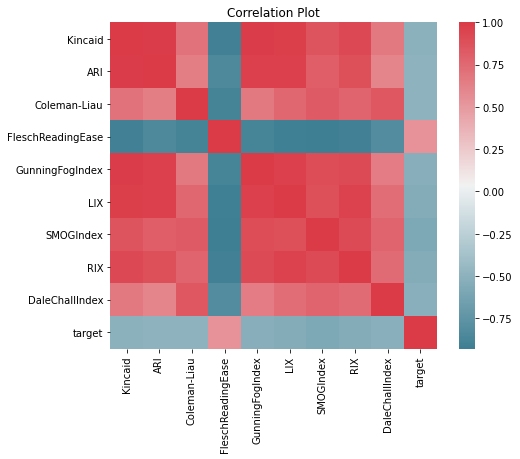

In [14]:
fig, ax =plt.subplots(figsize=(8, 6))
plt.title("Correlation Plot")
sns.heatmap(read_corr,
            mask=np.zeros_like(read_corr, dtype=np.bool),
            cmap=sns.diverging_palette(220, 10, as_cmap=True),
            square=True, ax=ax)
plt.show()

As expected, the readability grades are highly correlated with each other. So, using some or all of them will increase redundancy. Therefore, we will chose a single best readability grade, the one which is most correlated with target variable.

In [15]:
read_corr.target

Kincaid             -0.513972
ARI                 -0.489209
Coleman-Liau        -0.490741
FleschReadingEase    0.536111
GunningFogIndex     -0.535571
LIX                 -0.551215
SMOGIndex           -0.586719
RIX                 -0.553279
DaleChallIndex      -0.523827
target               1.000000
Name: target, dtype: float64

**SMOGIndex** is the most correlated with the target variable. So, it is best to use it for training.

Now, we will take all the features readabiltiy module can give us and then remove them by calculating their correlation with each other and with the target variable.

In [16]:
X = pd.DataFrame(train_data['id'])
X.loc[:,'readability'] = train_data.apply(lambda row: row.readability_object['readability grades']['SMOGIndex'], axis=1)
X.loc[:,'sentiment'] = train_data.apply(lambda row: sentiment_analysis(row.excerpt), axis=1)
X.loc[:,'characters_per_word'] = train_data.apply(lambda row: row.readability_object['sentence info']['characters_per_word'], axis=1)
X.loc[:,'syll_per_word'] = train_data.apply(lambda row: row.readability_object['sentence info']['syll_per_word'], axis=1)
X.loc[:,'words_per_sentence'] = train_data.apply(lambda row: row.readability_object['sentence info']['words_per_sentence'], axis=1)
X.loc[:,'sentences_per_paragraph'] = train_data.apply(lambda row: row.readability_object['sentence info']['sentences_per_paragraph'], axis=1)
X.loc[:,'type_token_ratio'] = train_data.apply(lambda row: row.readability_object['sentence info']['type_token_ratio'], axis=1)
X.loc[:,'characters'] = train_data.apply(lambda row: row.readability_object['sentence info']['characters'], axis=1)
X.loc[:,'syllables'] = train_data.apply(lambda row: row.readability_object['sentence info']['syllables'], axis=1)
X.loc[:,'words'] = train_data.apply(lambda row: row.readability_object['sentence info']['words'], axis=1)
X.loc[:,'wordtypes'] = train_data.apply(lambda row: row.readability_object['sentence info']['wordtypes'], axis=1)
X.loc[:,'sentences'] = train_data.apply(lambda row: row.readability_object['sentence info']['sentences'], axis=1)
X.loc[:,'long_words'] = train_data.apply(lambda row: row.readability_object['sentence info']['long_words'], axis=1)
X.loc[:,'complex_words'] = train_data.apply(lambda row: row.readability_object['sentence info']['complex_words'], axis=1)
X.loc[:,'complex_words_dc'] = train_data.apply(lambda row: row.readability_object['sentence info']['complex_words_dc'], axis=1)
X.loc[:,'tobeverb'] = train_data.apply(lambda row: row.readability_object['word usage']['tobeverb'], axis=1)
X.loc[:,'auxverb'] = train_data.apply(lambda row: row.readability_object['word usage']['auxverb'], axis=1)
X.loc[:,'conjunction'] = train_data.apply(lambda row: row.readability_object['word usage']['conjunction'], axis=1)
X.loc[:,'pronoun'] = train_data.apply(lambda row: row.readability_object['word usage']['pronoun'], axis=1)
X.loc[:,'preposition'] = train_data.apply(lambda row: row.readability_object['word usage']['preposition'], axis=1)
X.loc[:,'nominalization'] = train_data.apply(lambda row: row.readability_object['word usage']['nominalization'], axis=1)

In [17]:
X.info()
X.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2834 entries, 0 to 2833
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       2834 non-null   object 
 1   readability              2834 non-null   float64
 2   sentiment                2834 non-null   float64
 3   characters_per_word      2834 non-null   float64
 4   syll_per_word            2834 non-null   float64
 5   words_per_sentence       2834 non-null   float64
 6   sentences_per_paragraph  2834 non-null   float64
 7   type_token_ratio         2834 non-null   float64
 8   characters               2834 non-null   int64  
 9   syllables                2834 non-null   int64  
 10  words                    2834 non-null   int64  
 11  wordtypes                2834 non-null   int64  
 12  sentences                2834 non-null   int64  
 13  long_words               2834 non-null   int64  
 14  complex_words           

,id,readability,sentiment,characters_per_word,syll_per_word,words_per_sentence,sentences_per_paragraph,type_token_ratio,characters,syllables,...,sentences,long_words,complex_words,complex_words_dc,tobeverb,auxverb,conjunction,pronoun,preposition,nominalization
0,c12129c31,9.809085,0.134848,4.348066,1.220994,16.454545,11.0,0.607735,787,221,...,11,30,17,40,12,1,11,8,23,1
1,85aa80a4c,7.898979,0.133999,4.121387,1.190751,11.533333,15.0,0.676301,713,206,...,15,26,12,30,5,4,7,30,22,0
2,b69ac6792,8.916080,0.082672,4.000000,1.183908,14.500000,12.0,0.706897,696,206,...,12,25,14,42,8,0,11,24,18,0
3,dd1000b26,7.242641,0.333869,4.269461,1.167665,33.400000,5.0,0.676647,713,195,...,5,22,3,32,1,0,15,12,26,0
4,37c1b32fb,5.449490,0.198611,3.609272,0.973510,30.200000,5.0,0.317881,545,147,...,5,2,1,7,4,0,10,6,10,0


In [18]:
corr = X.corr()
corr.info()
corr

<class 'pandas.core.frame.DataFrame'>
Index: 21 entries, readability to nominalization
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   readability              21 non-null     float64
 1   sentiment                21 non-null     float64
 2   characters_per_word      21 non-null     float64
 3   syll_per_word            21 non-null     float64
 4   words_per_sentence       21 non-null     float64
 5   sentences_per_paragraph  21 non-null     float64
 6   type_token_ratio         21 non-null     float64
 7   characters               21 non-null     float64
 8   syllables                21 non-null     float64
 9   words                    21 non-null     float64
 10  wordtypes                21 non-null     float64
 11  sentences                21 non-null     float64
 12  long_words               21 non-null     float64
 13  complex_words            21 non-null     float64
 14  complex_wor

,readability,sentiment,characters_per_word,syll_per_word,words_per_sentence,sentences_per_paragraph,type_token_ratio,characters,syllables,words,...,sentences,long_words,complex_words,complex_words_dc,tobeverb,auxverb,conjunction,pronoun,preposition,nominalization
readability,1.000000,0.016079,0.750001,0.795921,0.592850,-0.581902,0.185608,0.535972,0.664062,-0.028995,...,-0.581902,0.767218,0.860790,0.627945,0.097186,-0.097539,-0.036712,-0.478316,0.272378,0.589163
sentiment,0.016079,1.000000,-0.011842,-0.008691,0.031830,-0.048405,0.040454,-0.012257,-0.011255,-0.002506,...,-0.048405,-0.028972,-0.017724,-0.055291,-0.010370,0.009243,0.036200,0.057940,-0.006641,0.029346
characters_per_word,0.750001,-0.011842,1.000000,0.948237,0.128959,-0.240383,0.221680,0.677986,0.757853,-0.084059,...,-0.240383,0.910801,0.851158,0.805179,0.078622,-0.139869,-0.121064,-0.611673,0.081549,0.581074
syll_per_word,0.795921,-0.008691,0.948237,1.000000,0.148318,-0.253791,0.195649,0.642115,0.803680,-0.079742,...,-0.253791,0.896194,0.901472,0.791816,0.131772,-0.113757,-0.113999,-0.568226,0.084259,0.599864
words_per_sentence,0.592850,0.031830,0.128959,0.148318,1.000000,-0.763166,0.122939,0.086824,0.121737,-0.016923,...,-0.763166,0.143735,0.176159,0.045851,-0.076716,-0.065043,0.203772,-0.137052,0.317998,0.173820
sentences_per_paragraph,-0.581902,-0.048405,-0.240383,-0.253791,-0.763166,1.000000,-0.300945,-0.000079,-0.075756,0.250188,...,1.000000,-0.198768,-0.240739,-0.076408,0.117566,0.110878,-0.169792,0.261299,-0.287675,-0.212726
type_token_ratio,0.185608,0.040454,0.221680,0.195649,0.122939,-0.300945,1.000000,0.009778,0.043621,-0.216000,...,-0.300945,0.146397,0.098182,0.081226,-0.180486,-0.119585,-0.005775,-0.061789,0.018089,0.034634
characters,0.535972,-0.012257,0.677986,0.642115,0.086824,-0.000079,0.009778,1.000000,0.949749,0.671749,...,-0.000079,0.798759,0.715628,0.750521,0.207188,-0.014939,0.053085,-0.277855,0.372714,0.458059
syllables,0.664062,-0.011255,0.757853,0.803680,0.121737,-0.075756,0.043621,0.949749,1.000000,0.522989,...,-0.075756,0.865839,0.839324,0.800712,0.232166,-0.026254,0.017632,-0.344790,0.325299,0.535003
words,-0.028995,-0.002506,-0.084059,-0.079742,-0.016923,0.250188,-0.216000,0.671749,0.522989,1.000000,...,0.250188,0.161792,0.109388,0.204896,0.200869,0.121566,0.197677,0.244801,0.418489,0.033387


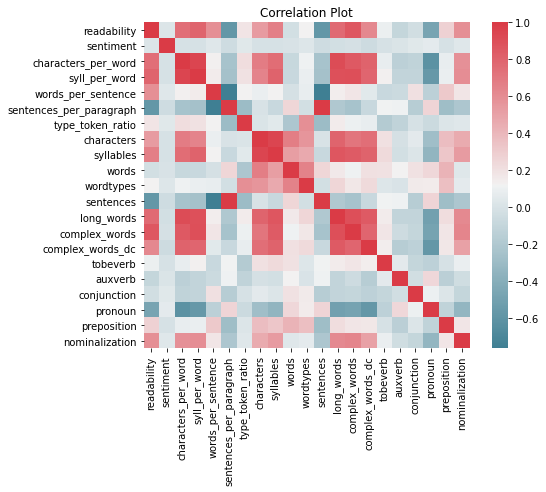

In [19]:
fig, ax =plt.subplots(figsize=(8, 6))
plt.title("Correlation Plot")
sns.heatmap(corr,
            mask=np.zeros_like(corr, dtype=np.bool),
            cmap=sns.diverging_palette(220, 10, as_cmap=True),
            square=True, ax=ax)
plt.show()

We can see that following groups of features has high correlation
 - characters_per_word and syll_per_word
 - characters and syllables
 - long_words, complex_words and complex_words_dc
 - sentences and sentences_per_paragraph
 
So, for all these three groups, we can only take one features.

In [20]:
tar_corr = pd.merge(X, train_data['target'], left_index=True, right_index=True).corr().loc['target']
tar_corr

readability               -0.586719
sentiment                  0.007563
characters_per_word       -0.426110
syll_per_word             -0.440768
words_per_sentence        -0.373027
sentences_per_paragraph    0.371925
type_token_ratio          -0.173452
characters                -0.406950
syllables                 -0.450932
words                     -0.119787
wordtypes                 -0.234083
sentences                  0.371925
long_words                -0.503766
complex_words             -0.508776
complex_words_dc          -0.475806
tobeverb                  -0.089089
auxverb                    0.099165
conjunction                0.023230
pronoun                    0.309482
preposition               -0.330622
nominalization            -0.401632
target                     1.000000
Name: target, dtype: float64

Correlations of features with target are **not very high** but still reasonable.

We can still remove features with very less correlation values like sentiment.